# Generate null brain maps for significance testing

This tutorial demonstrates how to use the eigenstrapping framework, developed by [Koussis *et al.* (2025)](https://doi.org/10.1162/IMAG.a.71), to generate null distributions for statistical analysis of associations between brain annotations. 

A null map, $y'(\vec{r})$, is generated according to the following equation:

$$y'(\vec{r})=\sum\limits_{\Lambda=0}^G\sum\limits_{\mu=-\Lambda}^\Lambda\bigg(\beta_{\Lambda\mu}\psi'_{\Lambda\mu}(\vec{r})\bigg)+\epsilon(\vec{r})$$

where:
- $\Lambda$ denotes the eigengroup
- $\mu$ denotes the eigenmode within the eigengroup
- $G$ is the maximum eigengroup
- $\beta_{\Lambda\mu}$ are the coefficients obtained by decomposing the original map onto the eigenmodes
- $\psi'_{\Lambda\mu}(\vec{r})$ are the new eigenmodes from the rotated eigengroup
- $\epsilon(\vec{r})$ is the residual term

In [1]:
from importlib.resources import files, as_file
import numpy as np
import matplotlib.pyplot as plt
from nsbutils.plotting import plot_surf
from neuromodes.eigen import EigenSolver, get_eigengroup_inds
from neuromodes.io import fetch_example_surf, fetch_example_map
from neuromodes.mesh import unmask_data
from neuromodes.stats import cdistw

In [2]:
# Configuration
density = "32k"
n_modes = 25**2   # First 25 eigengroups
n_nulls = 1000
seed = 0

We start by loading a mesh, initiating the `EigenSolver` class, and computing the eigenmodes.

In [ ]:
hemi = 'L'
surf_type = 'midthickness'
mesh, medmask = fetch_example_surf(density=density, hemi='L', surf_type='midthickness')

solver = EigenSolver(mesh, mask=medmask).solve(n_modes)

KeyboardInterrupt: 

In [22]:
empirical = fetch_example_map('ndi', density=density)[medmask]

In [30]:
from nibabel.loadsave import load
empirical = load("C:/Users/ipop0003/neuromaps-data/annotations/sydnor2021/SAaxis/fsLR/source-sydnor2021_desc-SAaxis_space-fsLR_den-32k_hemi-L_feature.func.gii").darrays[0].data[medmask]

In [32]:
# Calculate nulls
nulls = solver.eigenstrap(
    data=empirical,
    n_nulls=n_nulls,
    seed=seed,
    resample=None,
    residual='add'
)
print(nulls.shape)

(29696, 1000)


In [33]:
# calculate rayleigh quotient for myelinmap and its nulls
rq_empirical = (empirical.T @ solver.stiffness @ empirical) / (empirical.T @ solver.mass @ empirical)

rq_nulls = np.stack([(nulls[:, i].T @ solver.stiffness @ nulls[:, i]) / (nulls[:, i].T @ solver.mass @ nulls[:, i]) for i in range(n_nulls)])

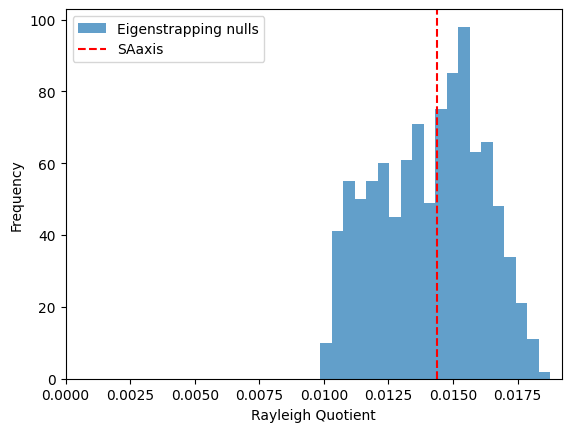

In [34]:
plt.hist(rq_nulls, bins=20, alpha=0.7, label='Eigenstrapping nulls')
plt.axvline(rq_empirical, color='red', linestyle='--', label='SAaxis')
plt.xlabel('Rayleigh Quotient')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0)
plt.show()